## Advanced Explainable AI for computer vision ###
Advanced explainable AI using the Grad-CAM method in Python focuses on visualizing why a deep convolutional neural network makes a particular decision. Grad-CAM (Gradient-weighted Class Activation Mapping) works by backpropagating the gradients of a target class score into the final convolutional layers and combining them to produce a coarse heatmap that highlights the most important regions in the input image. In Python, this is typically implemented with libraries such as PyTorch or TensorFlow/Keras, where you hook into the forward and backward passes of a trained model, compute the gradients for a chosen class, and then overlay the resulting activation map onto the original image. This provides an intuitive, human-interpretable explanation of model predictions, helping practitioners debug models, verify that they focus on meaningful features, and build trust in AI systems deployed in sensitive applications.

The library were are using to demonstrate the method is here: 
https://jacobgil.github.io/pytorch-gradcam-book/introduction.html

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import glob
import json
from dotenv import load_dotenv
from matplotlib import pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import albumentations as alb

from IPython.display import display, HTML

# We will use a library created by Jacob Gildenblat 
# https://github.com/jacobgil/pytorch-grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Import this module with autoreload
%load_ext autoreload
%autoreload 2
import computervision as cv
from computervision.fileutils import FileOP
from computervision.imageproc import ImageData, is_image
from computervision.datasets import DatasetFromDF
from computervision.models.lightningmodel import ToothModel
from computervision.inference import get_gpu_info

# Print version info
print(f'Package version: {cv.__version__}')
print(f'Authors:         {cv.__authors__}')
print(f'Python version:  {sys.version}')

Package version: v0.0.2
Authors:         The Core for Computational Biomedicine at Harvard Medical School
https://dbmi.hms.harvard.edu/about-dbmi/core-computational-biomedicine
Python version:  3.12.11 (main, Sep 14 2025, 14:48:49) [GCC 13.3.0]


In [2]:
is_cuda = torch.cuda.is_available()
print(f'CUDA available: {is_cuda}')
print(f'Number of GPUs found:  {torch.cuda.device_count()}')
if is_cuda:
    print(f'Current device ID:     {torch.cuda.current_device()}')
    print(f'GPU device name:       {torch.cuda.get_device_name(0)}')
    print(f'CUDNN version:         {torch.backends.cudnn.version()}')
    device_str = 'cuda:0'
    torch.cuda.empty_cache() 
else:
    device_str = 'cpu'
device = torch.device(device_str)
print()
print(f'Device for model training/inference: {device}')

CUDA available: True
Number of GPUs found:  1
Current device ID:     0
GPU device name:       NVIDIA GeForce RTX 3060 Laptop GPU
CUDNN version:         91002

Device for model training/inference: cuda:0


In [3]:
load_dotenv()
data_root = os.environ.get('DATA_DIR')
if data_root is None:
    print('Edit the "env"file and copy it to the root of the repository.') 
    raise FileNotFoundError('No .env file found. The data directory was not set.')

# Directory to store the data
dataset_name = 'computervision_data'
data_dir = os.path.join(data_root, dataset_name)
example_dir = os.path.join(data_dir, 'examples')
output_dir = os.path.join(example_dir, 'gradcam')
Path(output_dir).mkdir(parents=True, exist_ok=True)

# URL with the data set for manual download
url = 'https://dsets.s3.us-east-1.amazonaws.com/classification_datasets/dataset_dental_roboflow.tar.gz'
# url = os.environ.get('CL_URL')
image_dir_name = os.path.basename(url).split('.')[0]
image_dir = os.path.join(data_dir, image_dir_name, 'cropped')

# Verify the image data on disk
file_list = glob.glob(os.path.join(image_dir, '*.jpg'))
print(len(file_list))

# Directory for the trained model weights
model_dir = os.path.join(data_dir, 'model', 'lightningmodel')

7697


In [4]:
# Load the test data 
annotations_file_name = 'annotations_cropped_dset.parquet'
annotations_file = os.path.join(image_dir, annotations_file_name)
df = pd.read_parquet(annotations_file)

# Filter the test data
df = df.loc[df['dset'].isin(['test', 'val'])].\
    reset_index(drop=True)

file_col = 'file_name'
bbox_col= 'bbox'
label_col = 'label'
dset_col = 'dset'
pred_col = 'pred'
score_col = 'score'
pos_col = 'pos'

# Check the images
file_list = [os.path.join(image_dir, file_name) for file_name in df[file_col].unique()]
checked = [is_image(file) for file in file_list]
assert len(file_list) == sum(checked), f'WARNING: Could not open all {len(file_list)} images at: {image_dir}'
print(f'Image directory:        {image_dir}')
print(f'Total number of images: {len(file_list)}')
print(f'Annotations:            {df.shape[0]}')
display(df.head(2))

Image directory:        /home/andreas/data/computervision_data/dataset_dental_roboflow/cropped
Total number of images: 360
Annotations:            360


,multi_file,file_name,width,height,area,label,bbox,pos,pos_bbox,dset
0,59dace8b72.jpg,amalgam_08_59dace8b72.jpg,559,280,156520,amalgam,"[124, 57, 21, 34]","[19, 20]","[[143, 32, 414, 248], [20, 20, 227, 260]]",test
1,8001bf10f9.jpg,caries_02_8001bf10f9.jpg,477,238,113526,caries,"[261, 111, 58, 45]","[3, 4, 5]","[[20, 0, 367, 218], [205, 1, 272, 215], [301, ...",test


In [5]:
# Load the model from a checkpoint
model_name = 'lightningmodel'
model_number = 2
model_number_str = str(model_number).zfill(2)
model_dir_name = f'{model_name}_{model_number_str}'
checkpoint_dir = os.path.join(model_dir, model_dir_name)

checkpoint_files = sorted(list(glob.glob(os.path.join(checkpoint_dir, '*.ckpt'))))
checkpoint_names = [os.path.basename(file) for file in checkpoint_files]
checkpoint_dict = dict(zip(checkpoint_names, checkpoint_files))
print(f'Checkpoints found: {checkpoint_names}')

chk = 0
checkpoint_name = checkpoint_names[chk]
checkpoint_file = checkpoint_dict.get(checkpoint_name)
print(f'Checkpoint:      {checkpoint_name}')
print(f'Checkpoint file: {checkpoint_file}')

# Load model configuration
json_file = os.path.join(checkpoint_dir, f'{model_name}.json')
with open(json_file, 'r') as f:
    parameters = json.load(f)

id2label = parameters.get('id2label')

# We need to add the correct categories to the test data
id2label = {int(idx): label for idx, label in id2label.items()}
label2id = {label: idx for idx, label in id2label.items()}
df = df.assign(category=df[label_col].apply(lambda label: label2id.get(label)))
display(id2label)
display(df.head(2))

Checkpoints found: ['last.ckpt', 'model-epoch=13.ckpt', 'model-epoch=23.ckpt', 'model-epoch=28.ckpt']
Checkpoint:      last.ckpt
Checkpoint file: /home/andreas/data/computervision_data/model/lightningmodel/lightningmodel_02/last.ckpt


{0: 'tooth',
 1: 'amalgam',
 2: 'caries',
 3: 'composite',
 4: 'Calculus',
 5: 'root filling'}

,multi_file,file_name,width,height,area,label,bbox,pos,pos_bbox,dset,category
0,59dace8b72.jpg,amalgam_08_59dace8b72.jpg,559,280,156520,amalgam,"[124, 57, 21, 34]","[19, 20]","[[143, 32, 414, 248], [20, 20, 227, 260]]",test,1
1,8001bf10f9.jpg,caries_02_8001bf10f9.jpg,477,238,113526,caries,"[261, 111, 58, 45]","[3, 4, 5]","[[20, 0, 367, 218], [205, 1, 272, 215], [301, ...",test,2


In [6]:
# Initial scaling and padding for the bigger dimension
model_info = parameters.get('model_info')
max_image_size = model_info.get('max_image_size')
print(max_image_size)

# Model input size
im_width = model_info.get('im_width')
im_height = model_info.get('im_height')
print(im_width)
print(im_height)

# Resize and then normalize 
# with ImageNet mean and standard deviation for ResNet50
image_net_mean = ImageData().image_net_mean
image_net_std = ImageData().image_net_std

# This transform is essential and needs to be applies for both training and validation
resize_and_normalize = [alb.Resize(width=im_width, height=im_height),
                        alb.Normalize(mean=image_net_mean, std=image_net_std)]

# However, for validation and testing, we don't want the augmentations, 
# so we just resize and normalize the data
test_transform = alb.Compose(resize_and_normalize)

640
224
224


### Create a data loader for the model ###

In [7]:
# First, we need a data set from the data frame
test_dataset = DatasetFromDF(data=df,
                             image_dir=image_dir,
                             file_name_col=file_col,
                             label_id_col='category',
                             max_image_size=max_image_size,
                             transform=test_transform,
                             validate=True)

print(len(test_dataset))

# Then, we can create the data loader
batch_size = 16
dl = DataLoader(test_dataset,
                batch_size=batch_size,
                num_workers=1,
                shuffle=False)

360


### Load the model from the checkpoint and run inference on the test set ###

In [8]:
model = ToothModel.load_from_checkpoint(checkpoint_file,
                                        weights_only=False,
                                        test_dataset=test_dataset, 
                                        map_location=device,
                                        batch_size=batch_size,
                                        num_classes=len(id2label),
                                        num_workers=1)
sm = nn.Softmax(dim=1)

# Run the test images through the model to get the scores for each class
pred_df_batch_list = []
for image_batch, label_batch in dl:
    pred_df_batch = pd.DataFrame(sm(model(image_batch.to(device))).cpu().detach().numpy()).\
        assign(cl=list(label_batch.detach().numpy()))
    pred_df_batch_list.append(pred_df_batch)

pred_df = pd.concat(pred_df_batch_list, axis=0, ignore_index=True).\
    assign(checkpoint=checkpoint_name,
           model_name=model_name,
           model_number=model_number,
           file_name=df[file_col].tolist())

display(pred_df.head(2))
print(pred_df.shape)

,0,1,2,3,4,5,cl,checkpoint,model_name,model_number,file_name
0,0.011524,0.006941,0.227016,0.727428,0.025806,0.001285,1,last.ckpt,lightningmodel,2,amalgam_08_59dace8b72.jpg
1,0.161062,0.113591,0.131282,0.290269,0.302201,0.001595,2,last.ckpt,lightningmodel,2,caries_02_8001bf10f9.jpg


(360, 11)


In [9]:
# Run the test images through the model to get the scores for each class
pred_df_batch_list = []
for image_batch, label_batch in dl:
    pred_df_batch = pd.DataFrame(sm(model(image_batch.to(device))).cpu().detach().numpy()).\
        assign(cl=list(label_batch.detach().numpy()))
    pred_df_batch_list.append(pred_df_batch)

pred_df = pd.concat(pred_df_batch_list, axis=0, ignore_index=True).\
    assign(checkpoint=checkpoint_name,
           model_name=model_name,
           model_number=model_number,
           file_name=df[file_col].values)

In [10]:
display(pred_df.head(2))

,0,1,2,3,4,5,cl,checkpoint,model_name,model_number,file_name
0,0.011524,0.006941,0.227016,0.727428,0.025806,0.001285,1,last.ckpt,lightningmodel,2,amalgam_08_59dace8b72.jpg
1,0.161062,0.113591,0.131282,0.290269,0.302201,0.001595,2,last.ckpt,lightningmodel,2,caries_02_8001bf10f9.jpg


### Run a batch of test images through the model ###

Extracting batch 0 from the data set


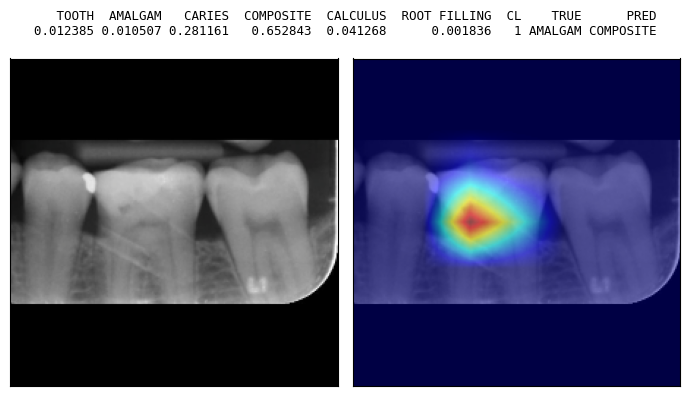

Extracting batch 1 from the data set


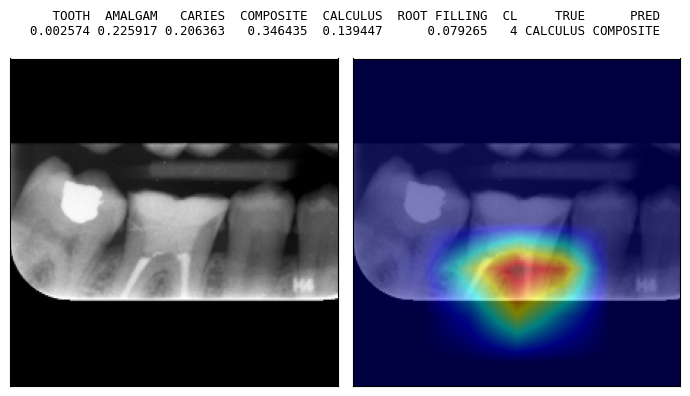

Extracting batch 2 from the data set


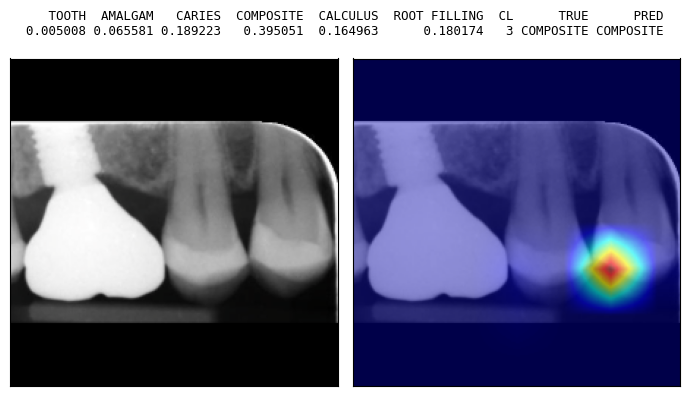

Extracting batch 3 from the data set


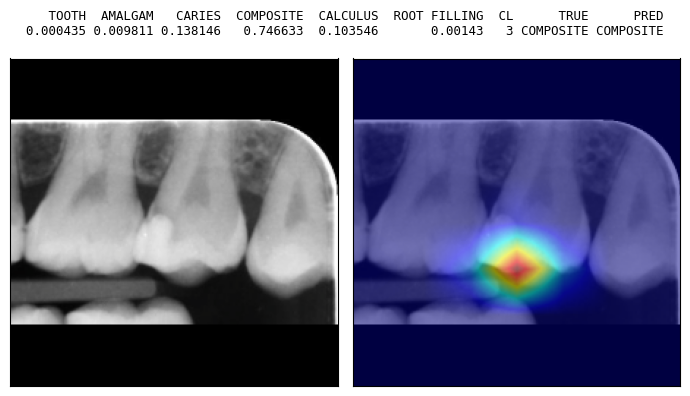

Extracting batch 4 from the data set


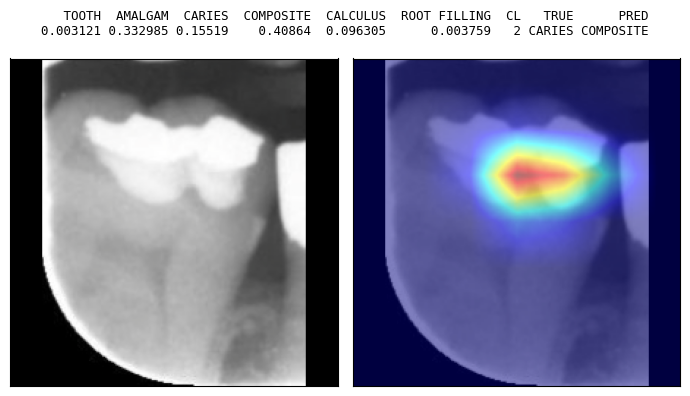

Extracting batch 5 from the data set


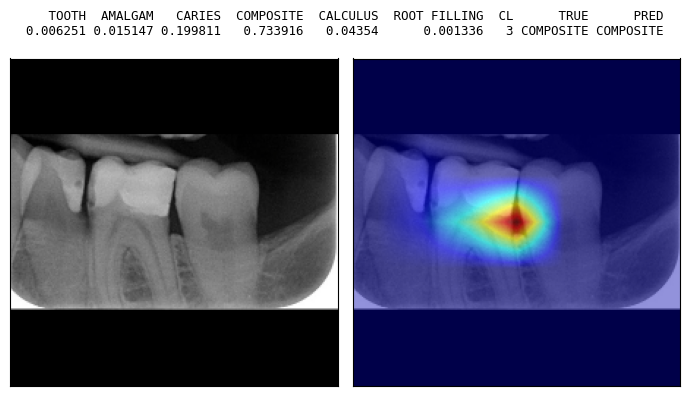

Extracting batch 6 from the data set


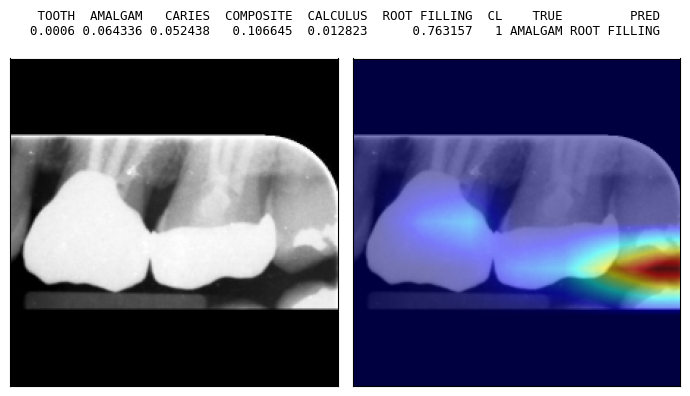

Extracting batch 7 from the data set


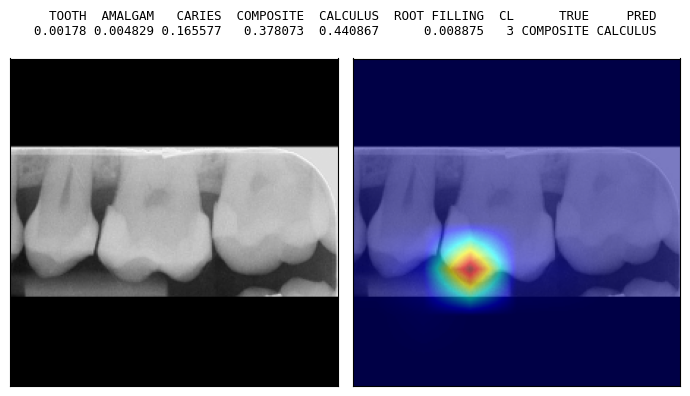

Extracting batch 8 from the data set


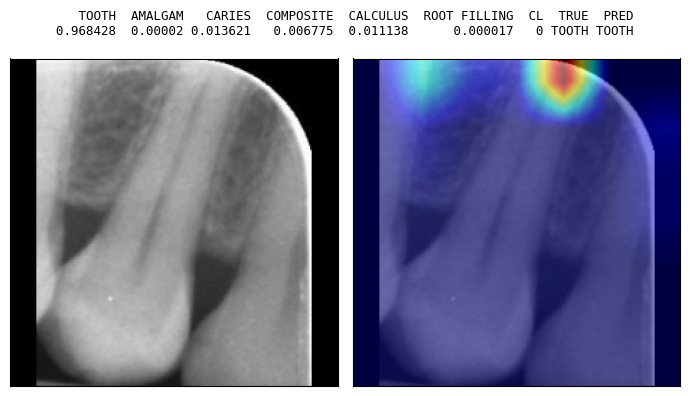

Extracting batch 9 from the data set


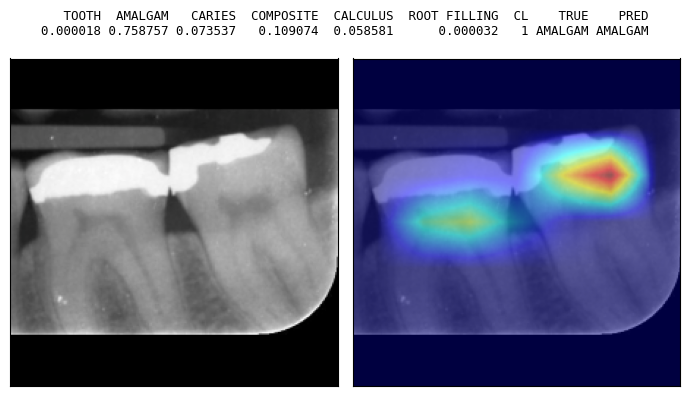

Extracting batch 10 from the data set


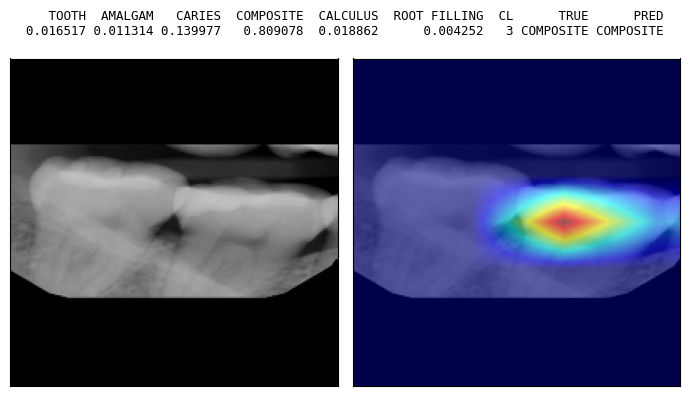

Extracting batch 11 from the data set


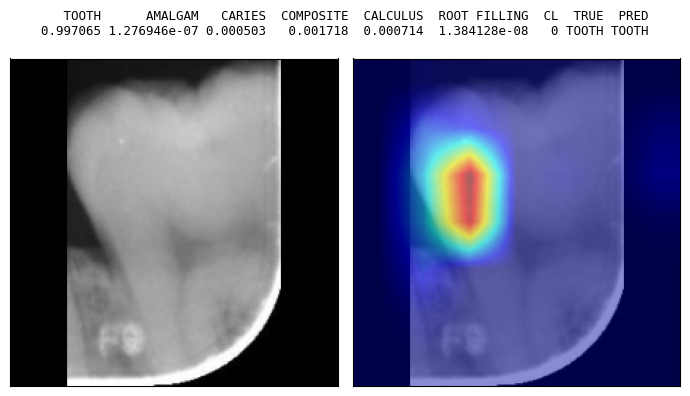

Extracting batch 12 from the data set


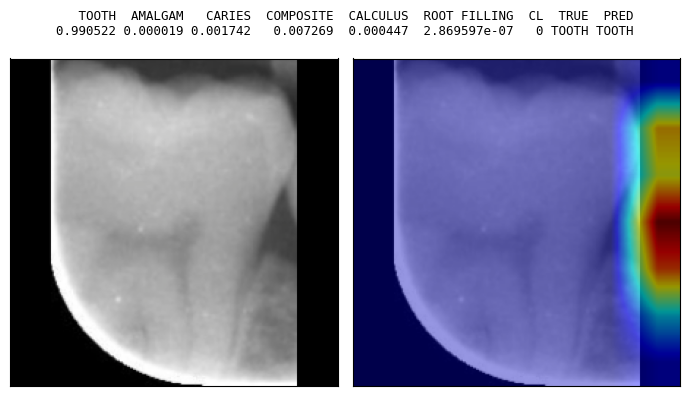

Extracting batch 13 from the data set


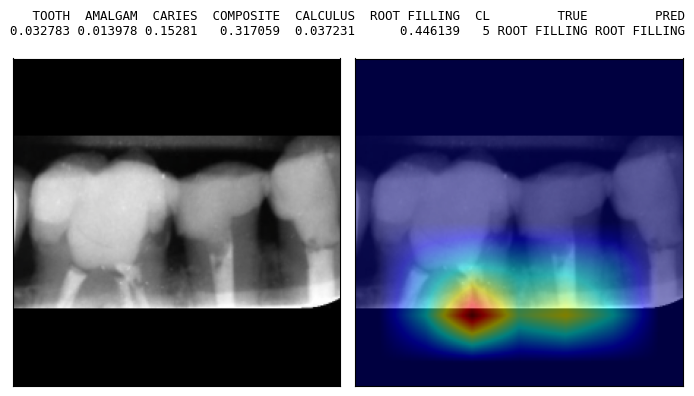

Extracting batch 14 from the data set


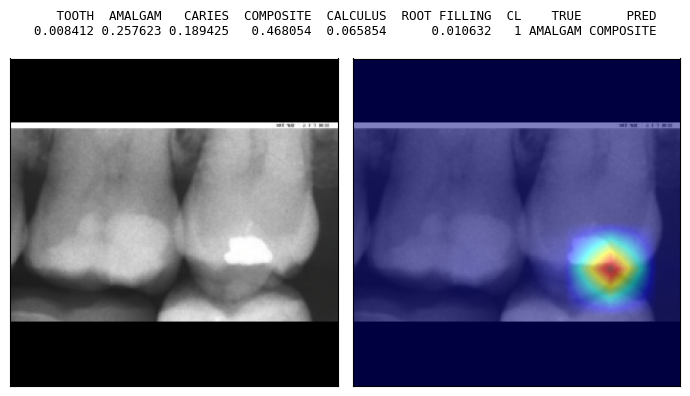

Extracting batch 15 from the data set


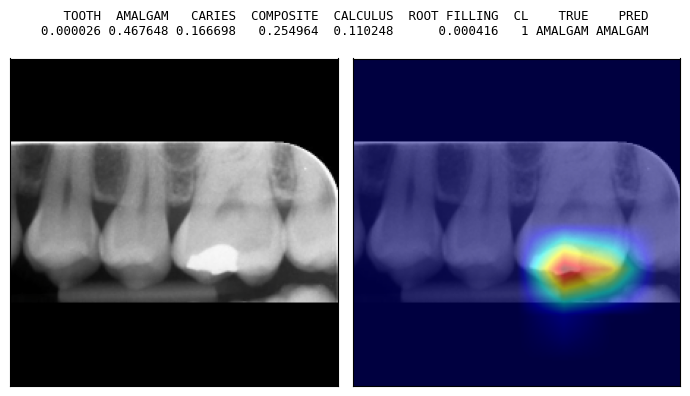

Extracting batch 16 from the data set


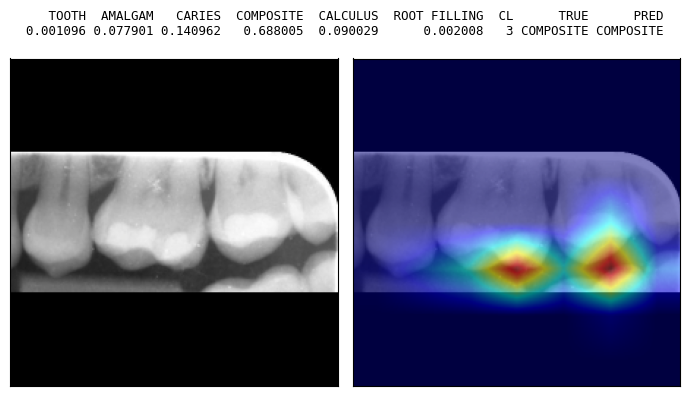

Extracting batch 17 from the data set


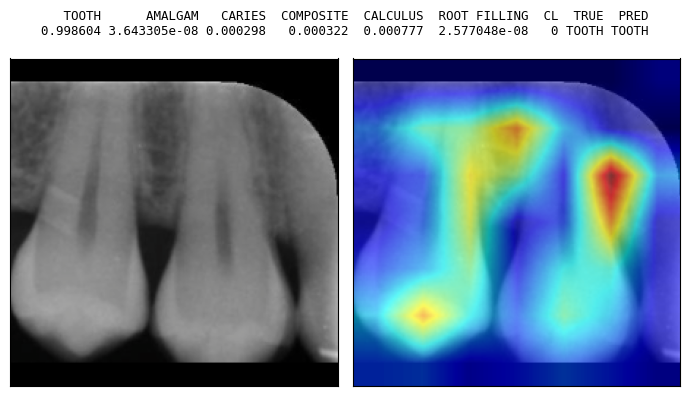

Extracting batch 18 from the data set


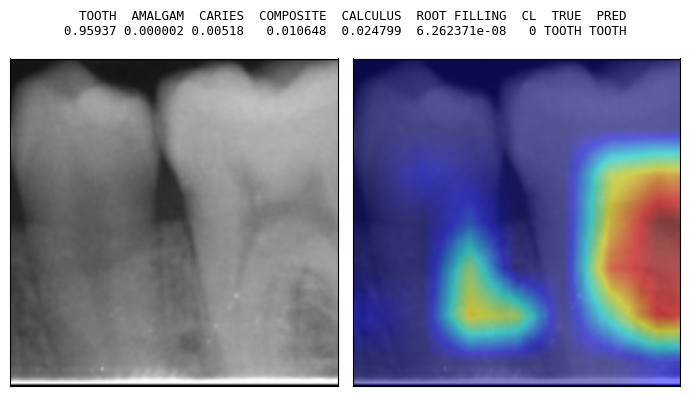

Extracting batch 19 from the data set


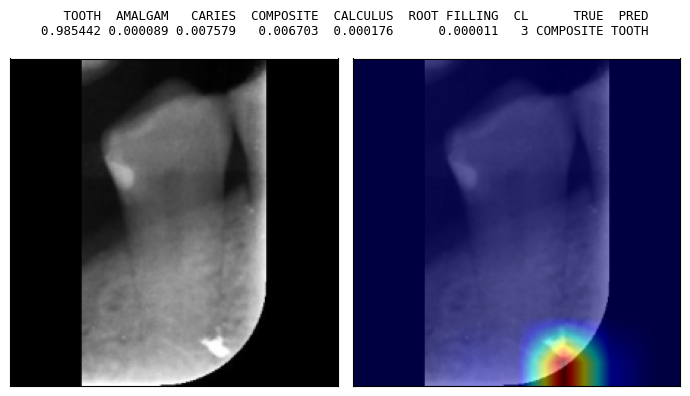

Extracting batch 20 from the data set


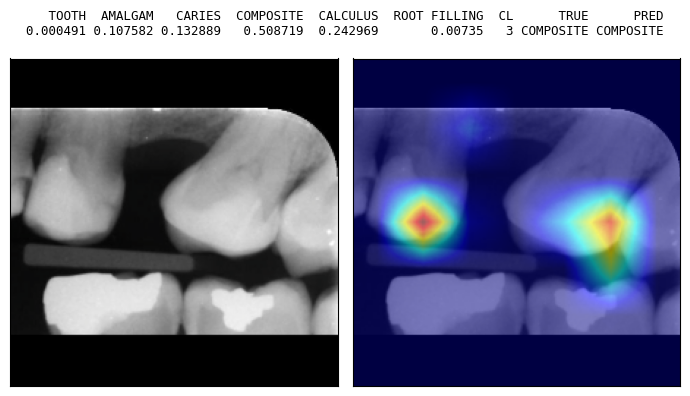

Extracting batch 21 from the data set


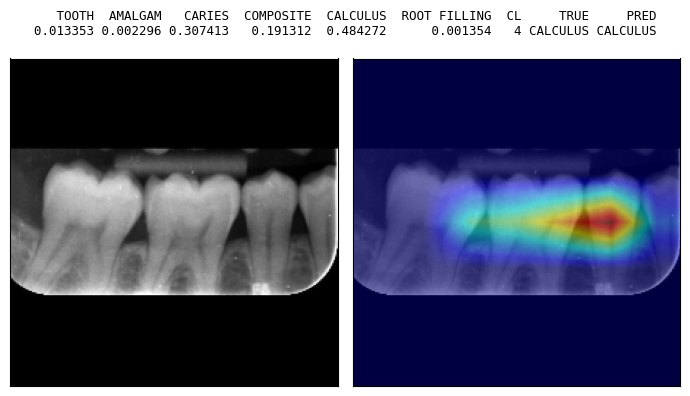

Extracting batch 22 from the data set


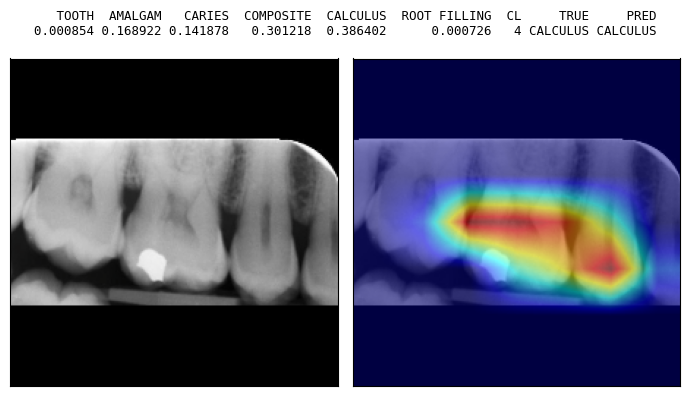

In [13]:
figsize = (7, 4)
for use_batch, (image_batch, label_batch) in enumerate(iter(dl)):
    print(f'Extracting batch {use_batch} from the data set')
    # Get the scores
    pred_df_batch = pd.DataFrame(sm(model(image_batch.to(device))).cpu().detach().numpy()).\
        assign(CL=list(label_batch.detach().numpy()))
    
    # Replace the column names
    cl_list = [id2label.get(i) for i in range(len(id2label))] 
    cl_list = [col.upper() for col in cl_list]
    col_list = cl_list.copy()
    col_list.extend(['CL'])
    
    pred_df_batch.columns = col_list
            
    # We need to convert the mean and std into tensors
    image_std = torch.tensor(image_net_std)
    image_mean = torch.tensor(image_net_mean)
    
    # Un-normalize the images in the batch
    image_list = [torch.permute(image, (1, 2, 0)) for image in image_batch]
    image_list = [(torch.mul(image, image_std) + image_mean).detach().numpy() for image in image_list]

    # Get the PyTorch model out of the Lightning instance
    torch_model = model.model
    
    # Target layers
    target_layers = [torch_model.layer4[-1]]
    
    # Ground truth labels
    target_labels = label_batch.numpy().tolist()
    
    #print(target_layers)
    targets = [ClassifierOutputTarget(t) for t in target_labels]
    
    # Instantiate the GradCAM class
    with GradCAM(model=torch_model, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=image_batch, targets=targets, aug_smooth=False, eigen_smooth=True)

    for idx, img in enumerate(image_list[:1]):
    
        true_cl = target_labels[idx]
        true_cl_name = id2label.get(true_cl).upper()
        score_cl = pred_df_batch.loc[pred_df_batch.index==idx]
        score_cl = score_cl.assign(TRUE=score_cl['CL'].apply(lambda cl: id2label.get(cl).upper()))
        score_cl_true = score_cl[true_cl_name].values[0]
    
        # Add the predicted class to the data frame
        pred_name = score_cl[cl_list].T.\
            sort_values(by=idx, ascending=False).\
            reset_index(drop=False).iloc[0]['index']
        score_cl = score_cl.assign(PRED=pred_name)
        
        img_title = f'{true_cl_name} Score: {score_cl_true:.3f}'
        img_name = f'{true_cl_name}_{use_batch}_{str(idx).zfill(2)}.png'
        img_file = os.path.join(output_dir, img_name)
        
        # Create the overlay image
        vis = show_cam_on_image(img=img,
                                mask=grayscale_cam[idx],
                                use_rgb=True,
                                image_weight=0.5)
        
        # Show the images
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=figsize)
        ax[0].imshow(img)
        ax[1].imshow(vis)
        # ax[1].set_title(img_title, fontsize=10)
        ax[0].set(xticks=[], yticks=[])
        ax[1].set(xticks=[], yticks=[])
        plt.tight_layout()
        plt.subplots_adjust(top=0.999)
        plt.suptitle(score_cl.to_string(index=False), fontsize=9, family='monospace', y=1.05)
        #plt.savefig(img_file, bbox_inches='tight')
        plt.show()